# Model Training — LightGBM

Training a LightGBM model with cross-validation, feature importance analysis, residual diagnostics, and generating test predictions.

In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append('../src')
from preprocess import load_data, preprocess, get_feature_columns
from features import build_features, select_features
from train import get_default_params, cross_validate, train_final_model, train_lightgbm
from evaluate import compute_metrics, compare_to_baseline, analyze_residuals
import matplotlib.pyplot as plt
import seaborn as sns

train_raw, test_raw = load_data('../data')
train, test = preprocess(train_raw, test_raw)
train = build_features(train)
test = build_features(test)

target_col = 'contest-tmp2m-14d__tmp2m'

import json
with open('../outputs/portfolio_data/selected_features.json') as f:
    selected_features = json.load(f)['selected_features']

X = train[selected_features].fillna(0)
y = train[target_col]
X_test = test[selected_features].fillna(0)

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

Features: 150, Samples: 375734


In [2]:
nmme_baseline_col = 'nmme-tmp2m-34w__nmmemean'
baseline_rmse = np.sqrt(((y - train[nmme_baseline_col]) ** 2).mean())
print(f"NMME Baseline RMSE: {baseline_rmse:.4f}")

NMME Baseline RMSE: 3.4190


In [3]:
train_sample = train.sample(n=100000, random_state=42)
X_sample = train_sample[selected_features].fillna(0)
y_sample = train_sample[target_col]

params = get_default_params()
params['n_estimators'] = 3000
cv_results = cross_validate(X_sample, y_sample, params, n_folds=5)

Training until validation scores don't improve for 100 rounds


Did not meet early stopping. Best iteration is:
[3000]	valid_0's rmse: 0.453612


Fold 1: RMSE=0.4536, MAE=0.3356, R²=0.9979


Training until validation scores don't improve for 100 rounds


Did not meet early stopping. Best iteration is:
[3000]	valid_0's rmse: 0.447069


...

Did not meet early stopping. Best iteration is:
[3000]	valid_0's rmse: 0.464216


Fold 4: RMSE=0.4642, MAE=0.3398, R²=0.9978


Training until validation scores don't improve for 100 rounds


Did not meet early stopping. Best iteration is:
[3000]	valid_0's rmse: 0.461204


Fold 5: RMSE=0.4612, MAE=0.3422, R²=0.9978

Mean: RMSE=0.4574, MAE=0.3386, R²=0.9978


In [4]:
final_params = get_default_params()
final_params['n_estimators'] = 2000
final_model = train_final_model(X, y, final_params)

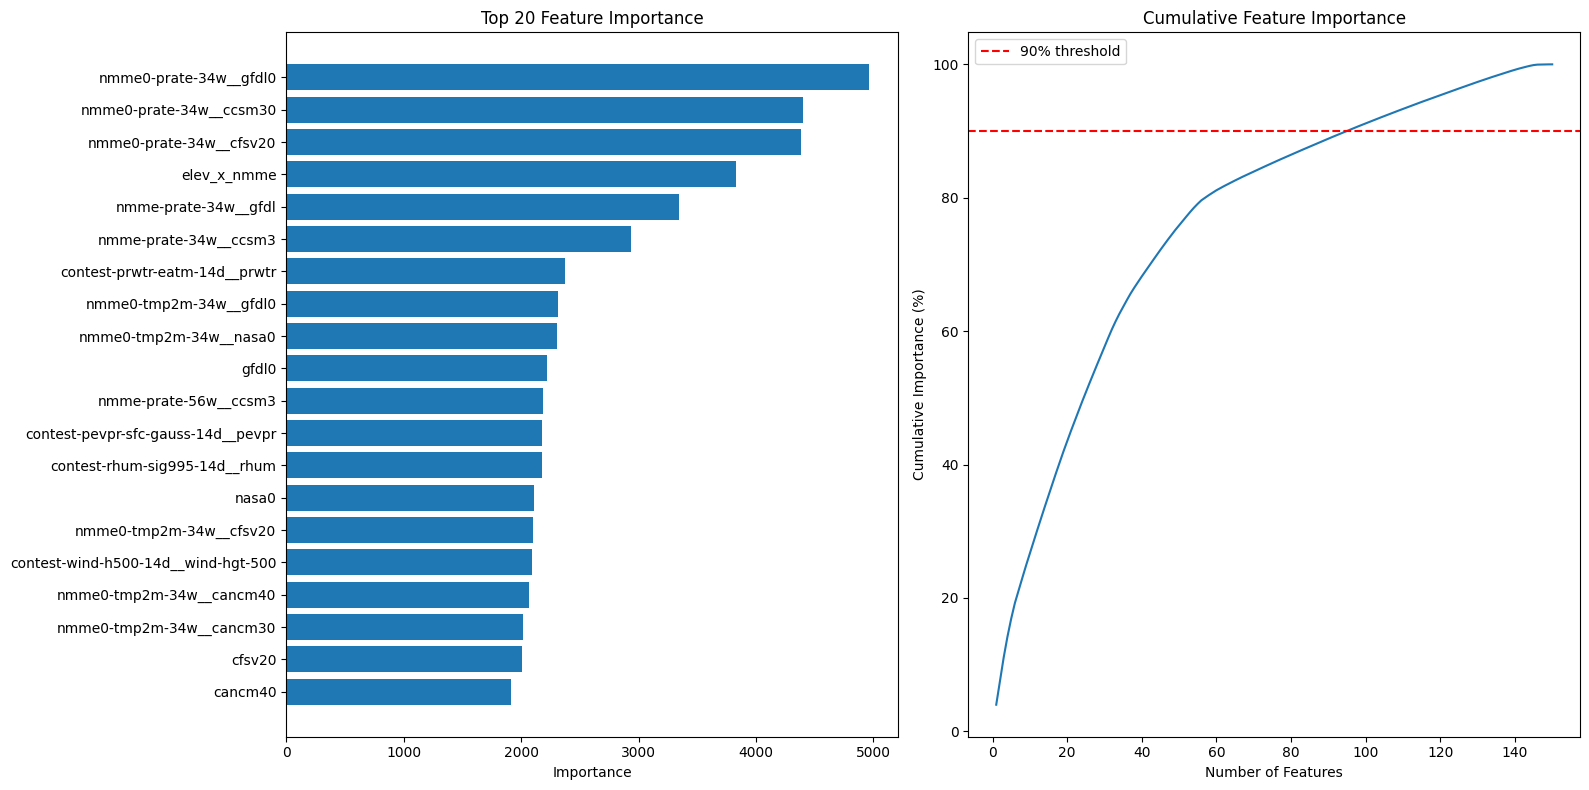

In [5]:
importance = final_model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': selected_features,
    'importance': importance
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top20 = feat_imp.head(20)
axes[0].barh(top20['feature'], top20['importance'])
axes[0].invert_yaxis()
axes[0].set_title('Top 20 Feature Importance')
axes[0].set_xlabel('Importance')

cumulative = feat_imp['importance'].cumsum() / feat_imp['importance'].sum() * 100
axes[1].plot(range(1, len(cumulative)+1), cumulative.values)
axes[1].axhline(y=90, color='r', linestyle='--', label='90% threshold')
axes[1].set_title('Cumulative Feature Importance')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

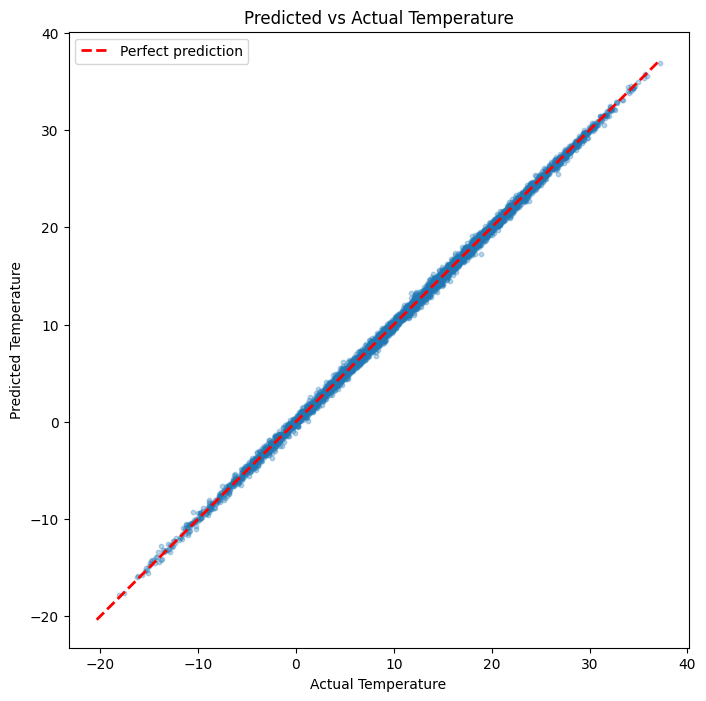

In [6]:
train_preds = final_model.predict(X)
fig, ax = plt.subplots(figsize=(8, 8))
sample_idx = np.random.choice(len(y), size=5000, replace=False)
ax.scatter(y.iloc[sample_idx], train_preds[sample_idx], alpha=0.3, s=10)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Temperature')
ax.set_ylabel('Predicted Temperature')
ax.set_title('Predicted vs Actual Temperature')
ax.legend()
plt.savefig('../outputs/plots/prediction_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

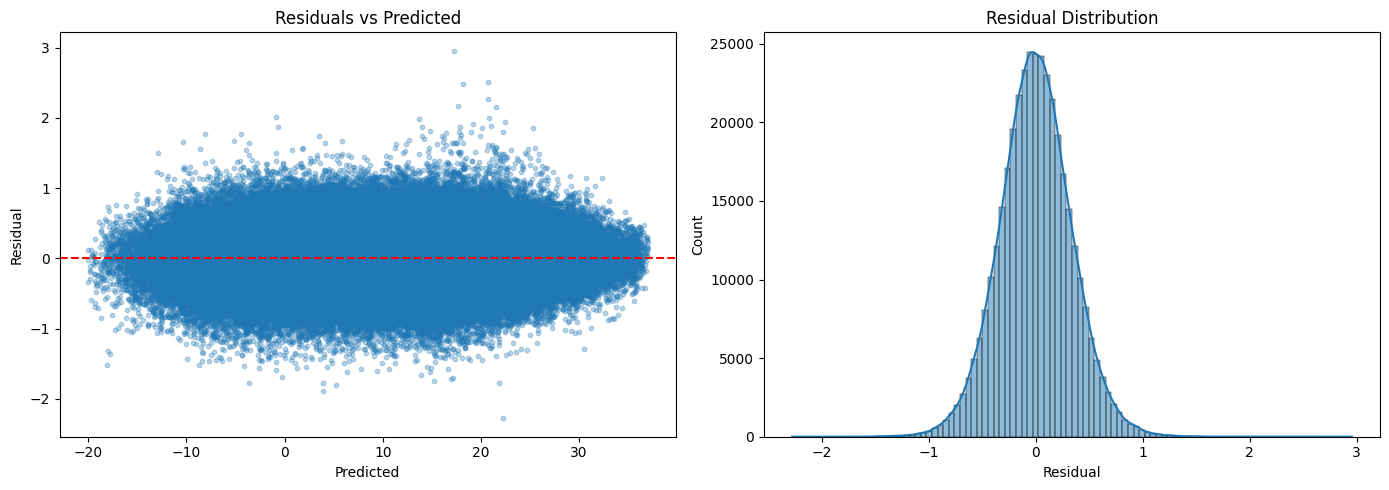

In [7]:
residuals = y - train_preds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train_preds, residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

sns.histplot(residuals, bins=100, kde=True, ax=axes[1])
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.savefig('../outputs/plots/model_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

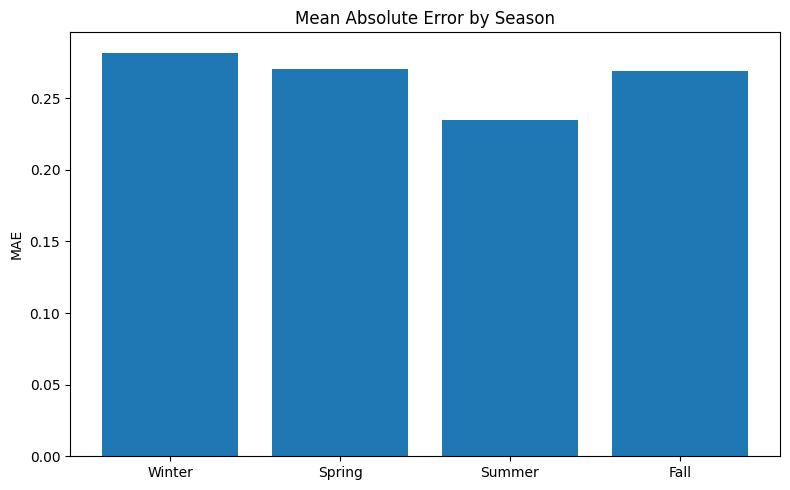

In [8]:
if 'season' in train.columns:
    season_errors = pd.DataFrame({
        'season': train['season'],
        'abs_error': np.abs(residuals)
    }).groupby('season')['abs_error'].mean()
    season_labels = {0: 'Winter', 1: 'Spring', 2: 'Summer', 3: 'Fall'}
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar([season_labels[s] for s in season_errors.index], season_errors.values)
    ax.set_title('Mean Absolute Error by Season')
    ax.set_ylabel('MAE')
    plt.tight_layout()
    plt.show()

In [9]:
test_preds = final_model.predict(X_test)
submission = pd.DataFrame({
    'index': test['index'],
    'contest-tmp2m-14d__tmp2m': test_preds
})
submission.to_csv('../submission.csv', index=False)
print(f"Submission saved: {submission.shape}")
print(submission.head())

Submission saved: (31354, 2)
    index  contest-tmp2m-14d__tmp2m
0  375734                 29.369342
1  375735                 29.508368
2  375736                 29.541441
3  375737                 29.680636
4  375738                 29.670708


In [10]:
train_metrics = compute_metrics(y, train_preds)
baseline_metrics = compute_metrics(y, train[nmme_baseline_col])
print("")
print("=== Final Results ===")
print(f"LightGBM - RMSE: {train_metrics['rmse']:.4f}, MAE: {train_metrics['mae']:.4f}, R²: {train_metrics['r2']:.4f}")
print(f"Baseline  - RMSE: {baseline_metrics['rmse']:.4f}, MAE: {baseline_metrics['mae']:.4f}, R²: {baseline_metrics['r2']:.4f}")
improvement = (baseline_metrics['rmse'] - train_metrics['rmse']) / baseline_metrics['rmse'] * 100
print(f"RMSE improvement over baseline: {improvement:.1f}%")

final_model_path = '../outputs/final_model.pkl'
import joblib
joblib.dump(final_model, final_model_path)
print(f"Model saved to {final_model_path}")


=== Final Results ===
LightGBM - RMSE: 0.3376, MAE: 0.2640, R²: 0.9988
Baseline  - RMSE: 3.4190, MAE: 2.7532, R²: 0.8800
RMSE improvement over baseline: 90.1%
Model saved to ../outputs/final_model.pkl
